## Numerical

Goal : ดูการกระจายตัว (Distribution) ว่าเบ้ (Skewed) ไหม? มี Outliers ที่ต้องจัดการไหม?

### Checking Distribution

In [3]:
import math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import importlib
import sys

from pathlib import Path
from IPython.display import display

sns.set_theme(style="whitegrid")


In [4]:
DATA_PATH = '../../data/processed/quality'

orders = pd.read_csv(Path(DATA_PATH) / 'orders_clean.csv')
order_products_prior = pd.read_csv(Path(DATA_PATH) / 'order_products_prior_clean.csv')

tables = {
    'orders': orders,
    'order_products_prior': order_products_prior,
}

In [5]:
palette_level = {
    'Strong': '#c8553d',
    'Moderate': '#4c956c',
    'Weak': '#577590',
    'None': '#b7b7a4'
}
churn_palette = {0: '#4c78a8', 1: '#e45756'}
level_order = ['Strong', 'Moderate', 'Weak', 'None']


--- Analyzing Table: orders ---


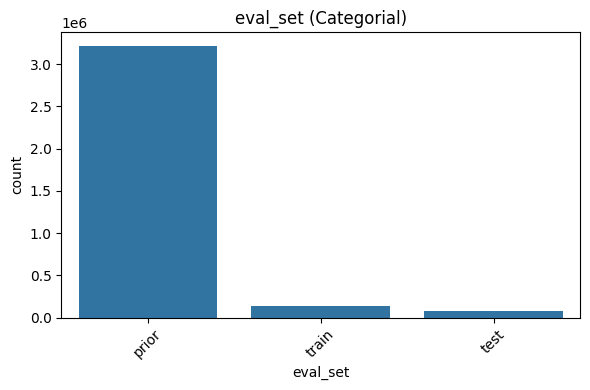

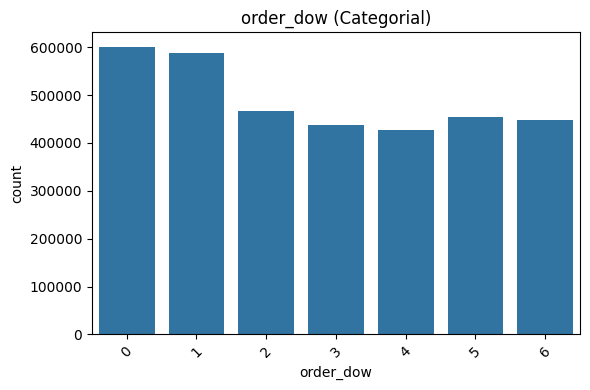

--- Analyzing Table: order_products_prior ---


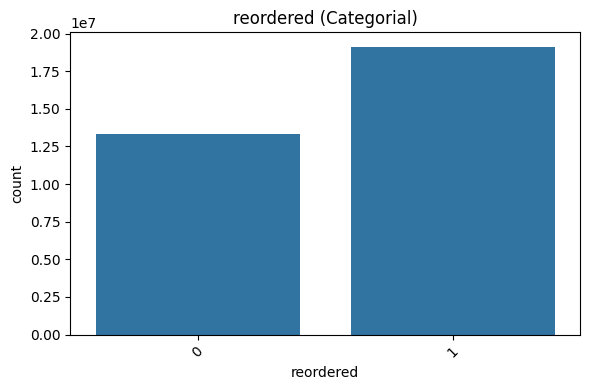

: 

In [ ]:
##Loop all columns
for table_name, df in tables.items():
    print(f"--- Analyzing Table: {table_name} ---")
    for col in df.columns:
        # 1. เช็คจำนวน Unique Values ก่อน
        unique_vals = df[col].nunique()
        title = "" #  ล้างค่า title ทุกครั้งที่เริ่มคอลัมน์ใหม่

        #Main Loop
        if df[col].dtype == "object" or unique_vals < 10:
            plt.figure(figsize=(6, 4))
            sns.countplot(x=col, data=df)
            plt.xticks(rotation=45)
            title = f"{col} (Categorial)"
    
        elif df[col].dtype in ["int64", "float64"]:

            if unique_vals < 20:
                plt.figure(figsize=(6, 4))
                sns.histplot(data=df, x=col, bins=unique_vals, kde=False)
                title = f"{col} (Discrete Numeric)"
        
            else:
                continue
        
        # 3. ใส่ Title และ Show เฉพาะอันที่มีการวาดรูปจริงๆ
        if title:
            plt.title(title)
            plt.tight_layout()
            plt.show()
